In [8]:
import sys
from pathlib import Path

# Get project root (go up one level from notebooks/)
project_root = Path().resolve().parent

# Add to Python path
sys.path.append(str(project_root))

In [9]:
from src.load_data import load_raw_data
from src.clean_data import clean_data
from src.features import prepare_features

df = load_raw_data()
df = clean_data(df)
df = prepare_features(df)

<Axes: xlabel='datetime'>

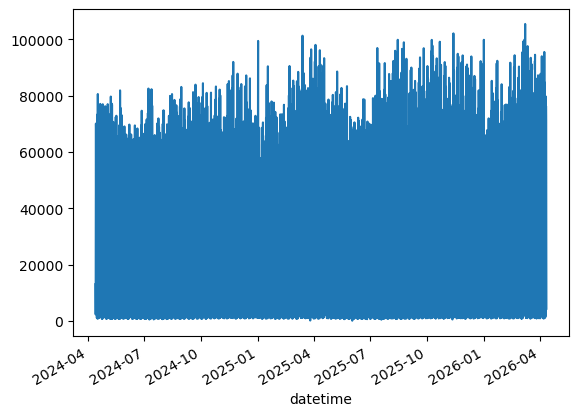

In [15]:
df.groupby("datetime").total_of_directions.sum().plot()

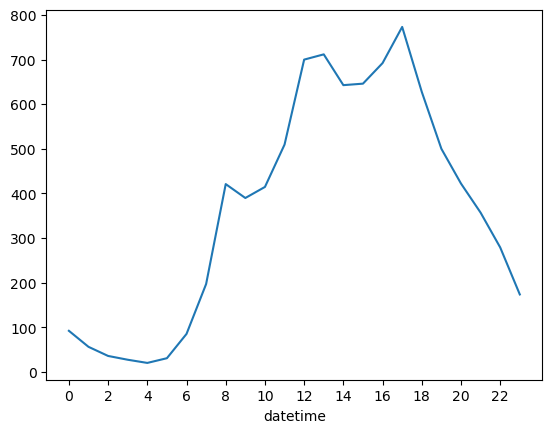

In [21]:
import matplotlib.pyplot as plt

ax = df.groupby(df["datetime"].dt.hour)["total_of_directions"].mean().plot()
ax.set_xticks(range(0, 24, 2))
plt.show()

We can see a spike at 8am, dropping a bit after, indicating commuter traffic for school and work. It picks back up around midday when most people will be having lunch. With the largest spike around 5pm, when most people are heading home after work/school. Continually drops from there.

<Axes: xlabel='datetime'>

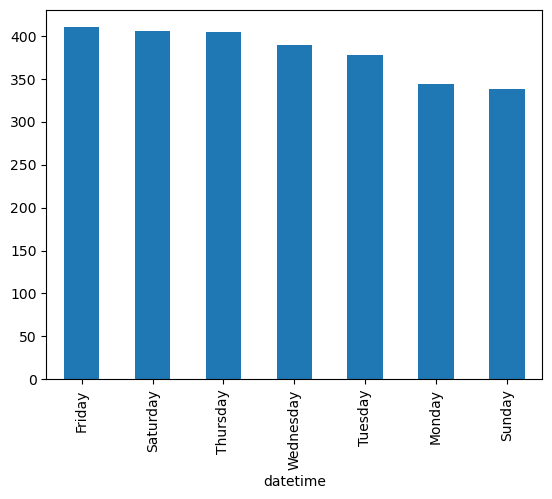

In [22]:
df.groupby(df["datetime"].dt.day_name())["total_of_directions"].mean().sort_values(ascending=False).plot(kind="bar")

Peak on Friday/Saturday, most people enjoying/ready for the weekend. Sunday and Monday are the lowest, people wanting to rest on sunday before the week begins, and people tired on Mondays, just getting on with it, less likely to do things.

In [13]:
df.groupby("sensor_name")["total_of_directions"].mean().sort_values()

sensor_name
EntPark1671_T      11.440210
WestWP_T           23.111582
Fli114C_T          29.373832
BirBridge_T        32.895794
Spen475_T          48.754146
                    ...     
Eli368_T         1190.767501
QVN_T            1202.430549
ElFi_T           1223.970311
SouthB_T         1367.850542
Swa31            1603.336098
Name: total_of_directions, Length: 98, dtype: float64

In [19]:
df["direction_ratio"] = df["direction_1"] / df["total_of_directions"]
print(df[["direction_ratio", "datetime"]])

         direction_ratio            datetime
0               0.500000 2026-04-12 03:00:00
1               0.666667 2026-04-12 03:00:00
2               0.364055 2026-04-12 03:00:00
3               0.555556 2026-04-12 03:00:00
4               0.000000 2026-04-12 03:00:00
...                  ...                 ...
1472097         0.638710 2024-04-13 00:00:00
1472098         0.430380 2024-04-13 00:00:00
1472099         0.394231 2024-04-13 00:00:00
1472100         0.750000 2024-04-13 00:00:00
1472101         0.423231 2024-04-13 00:00:00

[1472102 rows x 2 columns]
